# FEATURE ENGINEERING V2 + CHRONOS-2

### Thêm mới so với V1:
| Feature | Giải quyết điểm yếu | Nguồn |
|---------|---------------------|-------|
| **Elo Rating** | Recall Away Win thấp (50-51%) — thiếu strength of schedule | Horvat et al. (2023) |
| **Chronos-2 (4 features)** | Dự báo $t+1$ thay cho EMA ở các chỉ số nhạy phong độ | Amazon Chronos |
| **eFG% / TO Ratio / FT Rate** | Thiếu rate-based efficiency metrics | Oliver's Four Factors |

### Bộ features V2 (diff + B2B):
- DIFF_ từ Chronos-2: eFG_PCT, PTS, TO_RATIO, PLUS_MINUS
- DIFF_ từ EMA: FT_RATE, FT_PCT, OREB_PCT, DREB_PCT, AST, STL, BLK, PF
- DIFF_ bối cảnh: ELO, WIN_PCT, WIN_STREAK, REST_DAYS
- HOME_IS_B2B + AWAY_IS_B2B

---


# 0. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/datasets/nguyenbb/nba-new/nba_full_dataset (1).csv')
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

print(f'Dataset gốc: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Số trận: {df["GAME_ID"].nunique()}')
print(f'Mùa giải: {sorted(df["SEASON"].unique())}')
print(f'\nCác cột hiện có:')
print(list(df.columns))

Dataset gốc: 12300 dòng × 36 cột
Số trận: 6150
Mùa giải: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']

Các cột hiện có:
['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS', 'SEASON', 'IS_HOME', 'WIN', 'REST_DAYS', 'IS_B2B', 'GAMES_PLAYED_SEASON', 'CURRENT_WIN_PCT', 'WIN_STREAK']


# 1. Xử lý vấn đề phát hiện từ EDA (giống V1)

In [2]:
# 1.1 — Fill missing
df['FT_PCT'] = df['FT_PCT'].fillna(0)

# 1.2 — Cap REST_DAYS
print(f'REST_DAYS trước khi cap: min={df["REST_DAYS"].min()}, max={df["REST_DAYS"].max()}')
df['REST_DAYS'] = df['REST_DAYS'].clip(upper=10)
print(f'REST_DAYS sau khi cap:   min={df["REST_DAYS"].min()}, max={df["REST_DAYS"].max()}')

# 1.3 — Loại trận neutral site
game_home_count = df.groupby('GAME_ID')['IS_HOME'].sum()
neutral_games = game_home_count[game_home_count != 1].index
n_neutral = len(neutral_games)
df = df[~df['GAME_ID'].isin(neutral_games)].copy()

print(f'\nLoại {n_neutral} trận neutral site')
print(f'Dataset sau xử lý: {df.shape[0]} dòng, {df["GAME_ID"].nunique()} trận')

# Xác nhận
home_count = (df['IS_HOME'] == 1).sum()
away_count = (df['IS_HOME'] == 0).sum()
print(f'HOME: {home_count}, AWAY: {away_count} → {"Bằng nhau" if home_count == away_count else "❌ Lệch!"}')

REST_DAYS trước khi cap: min=1.0, max=9.0
REST_DAYS sau khi cap:   min=1.0, max=9.0

Loại 10 trận neutral site
Dataset sau xử lý: 12280 dòng, 6140 trận
HOME: 6140, AWAY: 6140 → Bằng nhau


# 2. (MỚI) Elo Rating

In [ ]:
K = 20
HOME_ADVANTAGE = 100
INITIAL_ELO = 1500
SEASON_CARRYOVER = 0.75  # 75% Elo cũ + 25% baseline

# Bước 2.1: Tạo danh sách trận (1 dòng/trận) để xử lý tuần tự
home_rows = df[df['IS_HOME'] == 1][['GAME_ID', 'GAME_DATE', 'SEASON', 'TEAM_ID', 'WIN']].copy()
home_rows.columns = ['GAME_ID', 'GAME_DATE', 'SEASON', 'HOME_TEAM_ID', 'HOME_WIN']
away_rows = df[df['IS_HOME'] == 0][['GAME_ID', 'TEAM_ID']].copy()
away_rows.columns = ['GAME_ID', 'AWAY_TEAM_ID']

games = home_rows.merge(away_rows, on='GAME_ID').sort_values(['GAME_DATE', 'GAME_ID']).reset_index(drop=True)
print(f'Danh sách trận: {len(games)} trận, sắp xếp theo thời gian')

# Bước 2.2: Tính Elo tuần tự
elo_ratings = {}  # TEAM_ID -> current Elo
game_elo = {}     # GAME_ID -> (home_elo_before, away_elo_before)
processed_seasons = set()

for _, game in games.iterrows():
    season = game['SEASON']
    home_id = game['HOME_TEAM_ID']
    away_id = game['AWAY_TEAM_ID']

    # Season reset
    if season not in processed_seasons:
        processed_seasons.add(season)
        if elo_ratings:
            for tid in elo_ratings:
                elo_ratings[tid] = SEASON_CARRYOVER * elo_ratings[tid] + (1 - SEASON_CARRYOVER) * INITIAL_ELO
            print(f'  Season reset → {season}: avg Elo = {np.mean(list(elo_ratings.values())):.1f}')

    # Khởi tạo
    if home_id not in elo_ratings:
        elo_ratings[home_id] = INITIAL_ELO
    if away_id not in elo_ratings:
        elo_ratings[away_id] = INITIAL_ELO

    R_home = elo_ratings[home_id]
    R_away = elo_ratings[away_id]

    # Lưu Elo TRƯỚC trận
    game_elo[game['GAME_ID']] = (R_home, R_away)

    # Expected (có home advantage +100)
    E_home = 1 / (1 + 10 ** ((R_away - (R_home + HOME_ADVANTAGE)) / 400))
    E_away = 1 - E_home

    # Update
    S_home = float(game['HOME_WIN'])
    S_away = 1.0 - S_home
    elo_ratings[home_id] = R_home + K * (S_home - E_home)
    elo_ratings[away_id] = R_away + K * (S_away - E_away)

# Bước 2.3: Map Elo về df (mỗi dòng = 1 đội trong 1 trận)
def get_elo(row):
    gid = row['GAME_ID']
    if gid in game_elo:
        home_elo, away_elo = game_elo[gid]
        return home_elo if row['IS_HOME'] == 1 else away_elo
    return INITIAL_ELO

df['ELO'] = df.apply(get_elo, axis=1)

print(f'\nĐã tính Elo cho {len(game_elo)} trận')
print(f'Elo range: {df["ELO"].min():.0f} → {df["ELO"].max():.0f}')
print(f'Elo mean: {df["ELO"].mean():.0f}')

Danh sách trận: 6140 trận, sắp xếp theo thời gian
  Season reset → 2022-23: avg Elo = 1500.0
  Season reset → 2023-24: avg Elo = 1500.0
  Season reset → 2024-25: avg Elo = 1500.0
  Season reset → 2025-26: avg Elo = 1500.0

Đã tính Elo cho 6140 trận
Elo range: 1201 → 1781
Elo mean: 1500


In [4]:
# Kiểm tra Elo — Top/Bottom đội cuối mỗi mùa
print('Top 5 Elo cao nhất cuối mỗi mùa:')
print('=' * 60)

for season in sorted(df['SEASON'].unique()):
    season_df = df[df['SEASON'] == season]
    # Lấy dòng cuối cùng của mỗi đội trong mùa
    last_game = season_df.sort_values('GAME_DATE').groupby('TEAM_ABBREVIATION').last()
    top5 = last_game.nlargest(5, 'ELO')[['ELO']]
    teams = ', '.join([f'{t}({e:.0f})' for t, e in zip(top5.index, top5['ELO'])])
    print(f'  {season}: {teams}')

Top 5 Elo cao nhất cuối mỗi mùa:
  2021-22: PHX(1697), MEM(1646), DAL(1624), BOS(1616), MIL(1611)
  2022-23: MIL(1672), BOS(1640), PHI(1636), CLE(1602), MEM(1596)
  2023-24: BOS(1707), DEN(1640), OKC(1634), MIN(1630), DAL(1610)
  2024-25: OKC(1759), BOS(1700), CLE(1688), LAC(1623), MIN(1610)
  2025-26: OKC(1761), SAS(1718), BOS(1674), DET(1658), NYK(1635)


# 3. Raw factors (per-game)

- Tính raw stats cho từng trận: eFG_PCT, TO_RATIO, FT_RATE, PLUS_MINUS, OREB_PCT, DREB_PCT
- OREB_PCT/DREB_PCT cần Opp_OREB/Opp_DREB → lấy từ dòng đối thủ trong cùng GAME_ID

In [5]:
# ============================================================
# RAW FACTORS — Tính cho từng trận (per-game)
# ============================================================

# 3.1 — eFG%: (FGM + 0.5 * FG3M) / FGA
df['eFG_PCT'] = (df['FGM'] + 0.5 * df['FG3M']) / df['FGA']

# 3.2 — Possessions (dùng để tính TO Ratio)
df['POSS'] = df['FGA'] + 0.44 * df['FTA'] - df['OREB'] + df['TOV']

# 3.3 — TO Ratio: TOV / Poss
df['TO_RATIO'] = df['TOV'] / df['POSS']
df['TO_RATIO'] = df['TO_RATIO'].fillna(0)

# 3.4 — FT Rate: FTM / FGA
df['FT_RATE'] = df['FTM'] / df['FGA']
df['FT_RATE'] = df['FT_RATE'].fillna(0)

# 3.5 — OREB% / DREB%: cần Opp_OREB / Opp_DREB
opp_stats = df[['GAME_ID', 'TEAM_ID', 'OREB', 'DREB']].copy()
opp_stats = opp_stats.rename(columns={
    'TEAM_ID': 'OPP_TEAM_ID',
    'OREB': 'OPP_OREB',
    'DREB': 'OPP_DREB',
})

# Merge theo GAME_ID để lấy dòng đối thủ
df = df.merge(opp_stats, on='GAME_ID', how='left')
df = df[df['TEAM_ID'] != df['OPP_TEAM_ID']].copy()

df['OREB_PCT'] = df['OREB'] / (df['OREB'] + df['OPP_DREB'])
df['DREB_PCT'] = df['DREB'] / (df['DREB'] + df['OPP_OREB'])
df['OREB_PCT'] = df['OREB_PCT'].fillna(0)
df['DREB_PCT'] = df['DREB_PCT'].fillna(0)

# Dọn cột tạm
df = df.drop(columns=['OPP_TEAM_ID', 'OPP_OREB', 'OPP_DREB'])

print('Raw factors — Thống kê:')
print('=' * 50)
for col in ['eFG_PCT', 'TO_RATIO', 'FT_RATE', 'OREB_PCT', 'DREB_PCT']:
    print(f'  {col:12s}: mean={df[col].mean():.4f}, std={df[col].std():.4f}, '
          f'min={df[col].min():.4f}, max={df[col].max():.4f}')

print(f'\nPOSS (possession estimate): mean={df["POSS"].mean():.1f}, std={df["POSS"].std():.1f}')

Raw factors — Thống kê:
  eFG_PCT     : mean=0.5437, std=0.0661, min=0.3193, max=0.8077
  TO_RATIO    : mean=0.1316, std=0.0367, min=0.0099, max=0.2969
  FT_RATE     : mean=0.2001, std=0.0730, min=0.0000, max=0.5789
  OREB_PCT    : mean=0.2435, std=0.0763, min=0.0000, max=0.5882
  DREB_PCT    : mean=0.7565, std=0.0763, min=0.4118, max=1.0000

POSS (possession estimate): mean=101.2, std=5.6


# 4. Chronos-2 Forecast + EMA (không leakage)

- Chronos-2 dự báo $t+1$ cho chuỗi univariate theo từng TEAM_ID
- Strict masking: chỉ dùng lịch sử trước trận hiện tại, không nhìn giá trị hiện tại
- Cold start: nếu lịch sử < 3 trận, để NaN (sẽ bị loại khi ghép)
- EMA chỉ dùng cho nhóm features còn lại


In [6]:
CHRONOS_FEATURES = ['eFG_PCT', 'PTS', 'TO_RATIO', 'PLUS_MINUS']

EMA_FEATURES = [
    'FT_RATE', 'FT_PCT', 'OREB_PCT', 'DREB_PCT', 
    'AST', 'STL', 'BLK', 'PF'
]

EMA_SPAN = 5
CHRONOS_MODEL = 'amazon/chronos-2'
CHRONOS_CONTEXT_LEN = 10
CHRONOS_MIN_CONTEXT = 3
CHRONOS_NUM_SAMPLES = 8
CHRONOS_INFERENCE_BATCH_SIZE = 4

print(f'Chronos features: {CHRONOS_FEATURES}')
print(f'EMA features: {EMA_FEATURES}')
print(f'EMA span: {EMA_SPAN}')
print(f'Chronos model: {CHRONOS_MODEL}')
print(f'Chronos samples per forecast: {CHRONOS_NUM_SAMPLES}')
print(f'Chronos batch size: {CHRONOS_INFERENCE_BATCH_SIZE}')


Chronos features: ['eFG_PCT', 'PTS', 'TO_RATIO', 'PLUS_MINUS']
EMA features: ['FT_RATE', 'FT_PCT', 'OREB_PCT', 'DREB_PCT', 'AST', 'STL', 'BLK', 'PF']
EMA span: 5
Chronos model: amazon/chronos-2
Chronos samples per forecast: 8
Chronos batch size: 4


In [7]:
%pip install chronos-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
Note: you may need to restart the kernel to use updated packages.


In [8]:
from chronos import Chronos2Pipeline
import torch
import pandas as pd
import numpy as np

# Sắp xếp theo đội + thời gian
df = df.sort_values(['TEAM_ID', 'SEASON', 'GAME_DATE']).reset_index(drop=True)

# Load Chronos-2 lên một GPU duy nhất để tránh lệch device giữa cuda:0 và cuda:1
pipeline = Chronos2Pipeline.from_pretrained(
    CHRONOS_MODEL,
    device_map='cuda',
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
)

def chronos_forecast_batch(group_series, context_len=CHRONOS_CONTEXT_LEN, min_context=CHRONOS_MIN_CONTEXT):
    """
    Hàm xử lý Batch Inference cho từng nhóm (Team + Season).
    """
    values = group_series.to_numpy()
    preds = np.full(len(values), np.nan)
    
    contexts = []
    valid_indices = []
    
    # Bước 1: Gom cụm toàn bộ context hợp lệ
    for i in range(len(values)):
        # Strict masking: chỉ dùng lịch sử trước trận i
        hist = values[:i]
        hist = hist[~np.isnan(hist)] 
        
        if len(hist) >= min_context:
            # Ép kiểu lịch sử thành torch.Tensor
            context_tensor = torch.tensor(hist[-context_len:], dtype=torch.float32)
            contexts.append(context_tensor)
            valid_indices.append(i)
            
    # Trả về NaN nếu không có trận nào trong nhóm đủ điều kiện tối thiểu
    if not contexts:
        return preds
        
    # Bước 2: BATCH INFERENCE theo cụm nhỏ để tiết kiệm VRAM
    for start in range(0, len(contexts), CHRONOS_INFERENCE_BATCH_SIZE):
        batch_contexts = contexts[start:start + CHRONOS_INFERENCE_BATCH_SIZE]
        batch_indices = valid_indices[start:start + CHRONOS_INFERENCE_BATCH_SIZE]
        
        with torch.inference_mode():
            forecast = pipeline.predict(
                batch_contexts,
                prediction_length=1,
                batch_size=CHRONOS_INFERENCE_BATCH_SIZE,
            )
            
        # Bước 3: Lấy forecast point từ quantile 0.5 của Chronos-2
        median_idx = pipeline.quantiles.index(0.5) if 0.5 in pipeline.quantiles else len(pipeline.quantiles) // 2
        
        # Bước 4: Ánh xạ kết quả trở lại vị trí gốc của mảng
        for idx, pred in zip(batch_indices, forecast):
            if pred.ndim == 3:
                point_pred = pred[0, median_idx, 0]
            elif pred.ndim == 2:
                point_pred = pred[median_idx, 0]
            else:
                point_pred = pred.reshape(-1)[0]
            preds[idx] = float(point_pred)
        
    return preds

# 4.1 — Chronos-2 dự báo cho các feature nhạy phong độ
for feat in CHRONOS_FEATURES:
    pred_col = f'CHRONOS_{feat}'
    
    # Dùng transform để chạy Batch Inference và điền trực tiếp vào DataFrame
    df[pred_col] = df.groupby(['TEAM_ID', 'SEASON'])[feat].transform(
        lambda x: chronos_forecast_batch(x)
    )
    print(f'Đã dự báo {pred_col}')

# 4.2 — EMA cho phần còn lại
for feat in EMA_FEATURES:
    col_name = f'EMA_{feat}'
    shifted = df.groupby(['TEAM_ID', 'SEASON'])[feat].shift(1)
    
    # Tối ưu bằng transform thay vì apply + reset_index
    df[col_name] = shifted.groupby([df['TEAM_ID'], df['SEASON']]).transform(
        lambda x: x.ewm(span=EMA_SPAN, min_periods=1).mean()
    )

print('Hoàn tất Chronos-2 + EMA')


2026-05-08 08:44:31.492139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778229871.724326      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778229871.794862      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778229872.339650      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778229872.339689      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778229872.339691      57 computation_placer.cc:177] computation placer alr

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Đã dự báo CHRONOS_eFG_PCT
Đã dự báo CHRONOS_PTS
Đã dự báo CHRONOS_TO_RATIO
Đã dự báo CHRONOS_PLUS_MINUS
Hoàn tất Chronos-2 + EMA


In [9]:
# Kiểm tra NaN
chronos_cols = [f'CHRONOS_{f}' for f in CHRONOS_FEATURES]
ema_cols = [f'EMA_{f}' for f in EMA_FEATURES]

nan_chronos = df[chronos_cols].isnull().any(axis=1).sum()
nan_ema = df[ema_cols].isnull().any(axis=1).sum()
print(f'Số dòng NaN ở Chronos: {nan_chronos}')
print(f'Số dòng NaN ở EMA:     {nan_ema}')
print('Các dòng NaN sẽ bị loại khi ghép 2 đội')

Số dòng NaN ở Chronos: 450
Số dòng NaN ở EMA:     150
Các dòng NaN sẽ bị loại khi ghép 2 đội


# 5. Ghép 2 đội thành 1 dòng/trận

Giống V1 nhưng thêm Chronos + EMA features + Elo

In [10]:
# Features giữ lại cho mỗi đội
team_features = (
    [f'CHRONOS_{f}' for f in CHRONOS_FEATURES]
    + [f'EMA_{f}' for f in EMA_FEATURES]
    + ['CURRENT_WIN_PCT', 'WIN_STREAK', 'REST_DAYS', 'IS_B2B', 'GAMES_PLAYED_SEASON']
    + ['ELO']
)
game_cols = ['GAME_ID', 'GAME_DATE', 'SEASON']

print(f'Features cho mỗi đội: {len(team_features)} cột')
print(f'  - Chronos: {len(CHRONOS_FEATURES)} cột')
print(f'  - EMA: {len(EMA_FEATURES)} cột')
print(f'  - Context: WIN_PCT, WIN_STREAK, REST_DAYS, IS_B2B, GAMES_PLAYED_SEASON')
print(f'  - Elo: 1 cột')

# Tách HOME / AWAY
home_df = df[df['IS_HOME'] == 1].copy()
away_df = df[df['IS_HOME'] == 0].copy()
print(f'\nHOME: {len(home_df)}, AWAY: {len(away_df)}')

# Rename
home_rename = {col: f'HOME_{col}' for col in team_features}
home_rename['TEAM_ABBREVIATION'] = 'HOME_TEAM'
home_rename['WIN'] = 'HOME_WIN'
away_rename = {col: f'AWAY_{col}' for col in team_features}
away_rename['TEAM_ABBREVIATION'] = 'AWAY_TEAM'

home_df = home_df.rename(columns=home_rename)
away_df = away_df.rename(columns=away_rename)

# Chọn cột + Merge
home_cols = game_cols + ['HOME_TEAM', 'HOME_WIN'] + [f'HOME_{f}' for f in team_features]
away_cols = ['GAME_ID', 'AWAY_TEAM'] + [f'AWAY_{f}' for f in team_features]

merged = home_df[home_cols].merge(away_df[away_cols], on='GAME_ID', how='inner')

# Loại NaN
before = len(merged)
merged = merged.dropna().reset_index(drop=True)
print(f'\nSau ghép: {before} → loại {before - len(merged)} NaN → còn {len(merged)} trận')
print(f'Shape: {merged.shape}')

Features cho mỗi đội: 18 cột
  - Chronos: 4 cột
  - EMA: 8 cột
  - Context: WIN_PCT, WIN_STREAK, REST_DAYS, IS_B2B, GAMES_PLAYED_SEASON
  - Elo: 1 cột

HOME: 6140, AWAY: 6140

Sau ghép: 6140 → loại 239 NaN → còn 5901 trận
Shape: (5901, 42)


In [11]:
# DIFF features từ Chronos
DIFF_FEATURES_CHRONOS = {
    'CHRONOS_eFG_PCT': 'DIFF_eFG_PCT',
    'CHRONOS_PTS': 'DIFF_PTS',
    'CHRONOS_TO_RATIO': 'DIFF_TO_RATIO',
    'CHRONOS_PLUS_MINUS': 'DIFF_PLUS_MINUS',
}

# DIFF features từ EMA
DIFF_FEATURES_EMA = {
    'EMA_FT_RATE': 'DIFF_FT_RATE',
    'EMA_FT_PCT': 'DIFF_FT_PCT',
    'EMA_OREB_PCT': 'DIFF_OREB_PCT',
    'EMA_DREB_PCT': 'DIFF_DREB_PCT',
    'EMA_AST': 'DIFF_AST',
    'EMA_STL': 'DIFF_STL',
    'EMA_BLK': 'DIFF_BLK',
    'EMA_PF': 'DIFF_PF',
}

# DIFF context
DIFF_FEATURES_CONTEXT = {
    'CURRENT_WIN_PCT': 'DIFF_WIN_PCT',
    'WIN_STREAK': 'DIFF_WIN_STREAK',
    'REST_DAYS': 'DIFF_REST_DAYS',
    'ELO': 'DIFF_ELO',
}

# Tất cả DIFF
DIFF_FEATURES_ALL = {**DIFF_FEATURES_CHRONOS, **DIFF_FEATURES_EMA, **DIFF_FEATURES_CONTEXT}

for feat, diff_name in DIFF_FEATURES_ALL.items():
    merged[diff_name] = merged[f'HOME_{feat}'] - merged[f'AWAY_{feat}']

print(f'Đã tạo {len(DIFF_FEATURES_ALL)} difference features:')
print(f'  Chronos: {len(DIFF_FEATURES_CHRONOS)}')
print(f'  EMA:     {len(DIFF_FEATURES_EMA)}')
print(f'  Context: {len(DIFF_FEATURES_CONTEXT)}')
print()

# Thống kê chi tiết
print(f'{"Feature":22s} {"Mean":>8s} {"Std":>8s}')
print('-' * 40)
for diff_name in DIFF_FEATURES_ALL.values():
    val = merged[diff_name]
    marker = ' ⭐' if diff_name in DIFF_FEATURES_CHRONOS.values() else ''
    print(f'{diff_name:22s} {val.mean():+8.3f} {val.std():8.3f}{marker}')

Đã tạo 16 difference features:
  Chronos: 4
  EMA:     8
  Context: 4

Feature                    Mean      Std
----------------------------------------
DIFF_eFG_PCT             -0.000    0.066 ⭐
DIFF_PTS                 -0.133   12.722 ⭐
DIFF_TO_RATIO            -0.000    0.037 ⭐
DIFF_PLUS_MINUS          +0.275   16.558 ⭐
DIFF_FT_RATE             +0.001    0.051
DIFF_FT_PCT              -0.001    0.073
DIFF_OREB_PCT            +0.001    0.060
DIFF_DREB_PCT            +0.001    0.052
DIFF_AST                 -0.059    4.057
DIFF_STL                 -0.017    2.173
DIFF_BLK                 -0.015    1.830
DIFF_PF                  -0.013    2.990
DIFF_WIN_PCT             -0.001    0.241
DIFF_WIN_STREAK          +0.059    4.798
DIFF_REST_DAYS           +0.083    1.002
DIFF_ELO                 +1.193  139.745


# 7. Định nghĩa bộ Features V2

- Bộ features V2: 18 cột
    - DIFF từ Chronos-2: 4
    - DIFF từ EMA: 8
    - DIFF bối cảnh: 4 (ELO, WIN_PCT, WIN_STREAK, REST_DAYS)
    - HOME_IS_B2B + AWAY_IS_B2B = 2
    - Tổng: 18 features


In [ ]:
feature_set_v2 = list(DIFF_FEATURES_ALL.values()) + ['HOME_IS_B2B', 'AWAY_IS_B2B']

print(f'Bộ V2 (mới): {len(feature_set_v2)} features')
print()
print('Features V2:')
for i, f in enumerate(feature_set_v2, 1):
    print(f'  {i:2d}. {f}')

Bộ V2 (mới): 18 features

Features V2:
   1. DIFF_eFG_PCT
   2. DIFF_PTS
   3. DIFF_TO_RATIO
   4. DIFF_PLUS_MINUS
   5. DIFF_FT_RATE
   6. DIFF_FT_PCT
   7. DIFF_OREB_PCT
   8. DIFF_DREB_PCT
   9. DIFF_AST
  10. DIFF_STL
  11. DIFF_BLK
  12. DIFF_PF
  13. DIFF_WIN_PCT
  14. DIFF_WIN_STREAK
  15. DIFF_REST_DAYS
  16. DIFF_ELO
  17. HOME_IS_B2B
  18. AWAY_IS_B2B


In [13]:
# Kiểm tra không NaN, không inf
v2_df = merged[feature_set_v2]
print('Kiểm tra chất lượng features V2:')
print(f'  NaN:  {v2_df.isnull().sum().sum()}')
print(f'  Inf:  {np.isinf(v2_df).sum().sum()}')
print(f'  Shape: {v2_df.shape}')

# Correlation với HOME_WIN
print(f'\nCorrelation với HOME_WIN:')
print('-' * 40)
for feat in feature_set_v2:
    corr = merged[feat].corr(merged['HOME_WIN'])
    print(f'  {feat:22s}: {corr:+.4f}')

Kiểm tra chất lượng features V2:
  NaN:  0
  Inf:  0
  Shape: (5901, 18)

Correlation với HOME_WIN:
----------------------------------------
  DIFF_eFG_PCT          : +0.1190
  DIFF_PTS              : +0.1090
  DIFF_TO_RATIO         : -0.0710
  DIFF_PLUS_MINUS       : +0.2050
  DIFF_FT_RATE          : +0.0513
  DIFF_FT_PCT           : +0.0674
  DIFF_OREB_PCT         : +0.0250
  DIFF_DREB_PCT         : +0.1010
  DIFF_AST              : +0.0772
  DIFF_STL              : +0.0456
  DIFF_BLK              : +0.0637
  DIFF_PF               : -0.0707
  DIFF_WIN_PCT          : +0.3254
  DIFF_WIN_STREAK       : +0.1962
  DIFF_REST_DAYS        : +0.0545
  DIFF_ELO              : +0.3437
  HOME_IS_B2B           : -0.0590
  AWAY_IS_B2B           : +0.0291


# 8. Train/Test split (2 lần chia)

In [14]:
# =============================================
# LẦN 1: Đánh giá (báo cáo)
# =============================================
eval_train_seasons = ['2021-22', '2022-23', '2023-24', '2024-25']
eval_test_season = '2025-26'

eval_train = merged[merged['SEASON'].isin(eval_train_seasons)].copy()
eval_test = merged[merged['SEASON'] == eval_test_season].copy()

print('LẦN 1 — ĐÁNH GIÁ MODEL (BÁO CÁO)')
print('=' * 50)
print(f'Train: {len(eval_train)} trận | {eval_train["GAME_DATE"].min()} → {eval_train["GAME_DATE"].max()}')
print(f'Test:  {len(eval_test)} trận | {eval_test["GAME_DATE"].min()} → {eval_test["GAME_DATE"].max()}')

assert eval_train['GAME_DATE'].max() < eval_test['GAME_DATE'].min(), '⚠️ Data leakage!'
print(f'Train HOME_WIN: {eval_train["HOME_WIN"].mean():.1%} | Test HOME_WIN: {eval_test["HOME_WIN"].mean():.1%}')

LẦN 1 — ĐÁNH GIÁ MODEL (BÁO CÁO)
Train: 4724 trận | 2021-10-25 00:00:00 → 2025-04-13 00:00:00
Test:  1177 trận | 2025-10-27 00:00:00 → 2026-04-12 00:00:00
Train HOME_WIN: 55.4% | Test HOME_WIN: 55.2%


In [15]:
# =============================================
# LẦN 2: Model cuối cùng (demo)
# =============================================
final_train = merged.copy()

print('LẦN 2 — MODEL CUỐI CÙNG (DEMO)')
print('=' * 50)
print(f'Train: {len(final_train)} trận (TẤT CẢ dữ liệu)')
print(f'Thời gian: {final_train["GAME_DATE"].min()} → {final_train["GAME_DATE"].max()}')
print(f'→ Predict: các trận SAU {final_train["GAME_DATE"].max()}')

LẦN 2 — MODEL CUỐI CÙNG (DEMO)
Train: 5901 trận (TẤT CẢ dữ liệu)
Thời gian: 2021-10-25 00:00:00 → 2026-04-12 00:00:00
→ Predict: các trận SAU 2026-04-12 00:00:00


In [16]:
# Tách X, y
LABEL = 'HOME_WIN'

# Lần 1 — Đánh giá
X_eval_train = eval_train[feature_set_v2]
X_eval_test  = eval_test[feature_set_v2]
y_eval_train = eval_train[LABEL]
y_eval_test  = eval_test[LABEL]

# Lần 2 — Demo
X_final = final_train[feature_set_v2]
y_final = final_train[LABEL]

print('SHAPES:')
print(f'  Lần 1: train {X_eval_train.shape}, test {X_eval_test.shape}')
print(f'  Lần 2: {X_final.shape}')
print(f'  Features: {len(feature_set_v2)} cột')
print(f'  Label: {LABEL}')

SHAPES:
  Lần 1: train (4724, 18), test (1177, 18)
  Lần 2: (5901, 18)
  Features: 18 cột
  Label: HOME_WIN


# 9. Lưu dataset V2

In [17]:
import os
import json

# Tạo thư mục con tên là 'output' ngay tại nơi chứa file Notebook hiện tại
save_dir = 'output'
os.makedirs(save_dir, exist_ok=True)

# Lưu các file CSV
merged.to_csv(f'{save_dir}/nba_model_ready_v2.csv', index=False)
eval_train.to_csv(f'{save_dir}/eval_train_v2.csv', index=False)
eval_test.to_csv(f'{save_dir}/eval_test_v2.csv', index=False)

print(f'Đã lưu 3 file CSV vào thư mục: {save_dir}/')

# Lưu config - Đã tối ưu cho cấu trúc V2
feature_config_v2 = {
    'version': 'v2',
    'label': 'HOME_WIN',
    'eval_train_seasons': eval_train_seasons,
    'eval_test_season': eval_test_season,
    'chronos_features': CHRONOS_FEATURES,
    'ema_features': EMA_FEATURES,
    'ema_span': EMA_SPAN,
    'chronos_model': CHRONOS_MODEL,
    'chronos_context_len': CHRONOS_CONTEXT_LEN,
    'chronos_num_samples': CHRONOS_NUM_SAMPLES,
    'chronos_inference_batch_size': CHRONOS_INFERENCE_BATCH_SIZE,
    'team_features': team_features,
    'elo_params': {
        'K': K,
        'home_advantage': HOME_ADVANTAGE,
        'initial_elo': INITIAL_ELO,
        'season_carryover': SEASON_CARRYOVER,
    },
    'changes_from_v1': [
        'Added Elo Rating (strength of schedule)',
        'Added Oliver Four Factors: eFG%, TO_RATIO, FT_RATE',
        'Changed from Rolling Mean to EMA (span=5)',
        'Integrated Amazon Chronos-2 for highly variant features',
    ],
}

with open(f'{save_dir}/feature_config_v2.json', 'w', encoding='utf-8') as f:
    json.dump(feature_config_v2, f, indent=2, ensure_ascii=False)

print(f'Đã lưu file config vào: {save_dir}/feature_config_v2.json')


Đã lưu 3 file CSV vào thư mục: output/
Đã lưu file config vào: output/feature_config_v2.json


## Tổng kết V2 + Chronos-2

| Bước | Mô tả | Kết quả |
|------|-------|---------|
| 0 | Load data | 12,108 dòng × 36 cột |
| 1 | Fix issues (giống V1) | Dữ liệu sạch |
| 2 | ⭐ **Elo Rating** | Strength of schedule cho mỗi đội |
| 3 | ⭐ **Raw factors** | eFG%, TO_RATIO, FT_RATE, OREB/DREB% |
| 4 | ⭐ **Chronos-2** | Dự báo $t+1$ cho 4 feature nhạy phong độ |
| 5 | EMA rolling | 8 EMA features/đội |
| 6 | Ghép 2 đội → 1 dòng | ~5900 trận |
| 7 | Difference features | Chronos + EMA + Context |
| 8 | Bộ features V2 | **18 features** |
| 9 | 2 lần chia | Đánh giá + Demo |
| 10 | Lưu file | CSV + JSON |


1. ĐANG LOAD DỮ LIỆU...
[+] Đã tự động nhận diện 18 features từ file CSV!
[+] X_train shape: (4724, 18) | y_train phân bố: 55.4% Home Win
[+] X_test shape:  (1177, 18)  | y_test phân bố:  55.2% Home Win

2. ĐANG HUẤN LUYỆN MÔ HÌNH...
[+] Huấn luyện xong!

3. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (OUT-OF-TIME)
--- Mô hình: Logistic Regression Baseline ---
Accuracy : 0.6814 (Độ chính xác tổng thể)
ROC-AUC  : 0.7350 (Khả năng phân tách Thắng/Thua)
F1-Score : 0.7220

Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.66      0.60      0.63       527
Home Win (1)       0.70      0.75      0.72       650

    accuracy                           0.68      1177
   macro avg       0.68      0.67      0.67      1177
weighted avg       0.68      0.68      0.68      1177



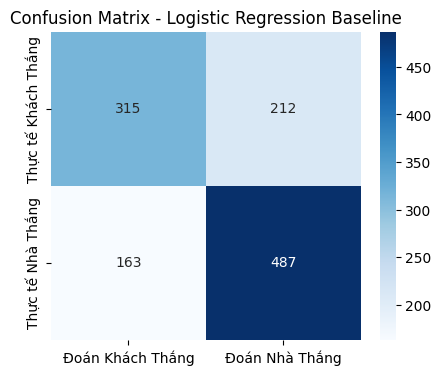



--- Mô hình: XGBoost Classifier ---
Accuracy : 0.6797 (Độ chính xác tổng thể)
ROC-AUC  : 0.7300 (Khả năng phân tách Thắng/Thua)
F1-Score : 0.7266

Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.67      0.57      0.61       527
Home Win (1)       0.69      0.77      0.73       650

    accuracy                           0.68      1177
   macro avg       0.68      0.67      0.67      1177
weighted avg       0.68      0.68      0.68      1177



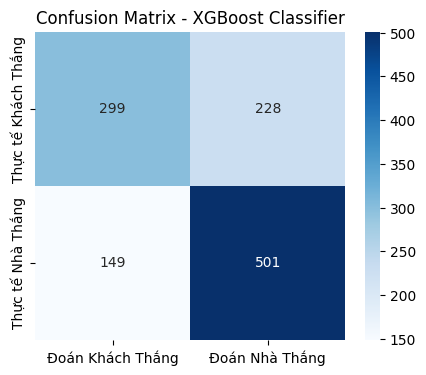


4. MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)


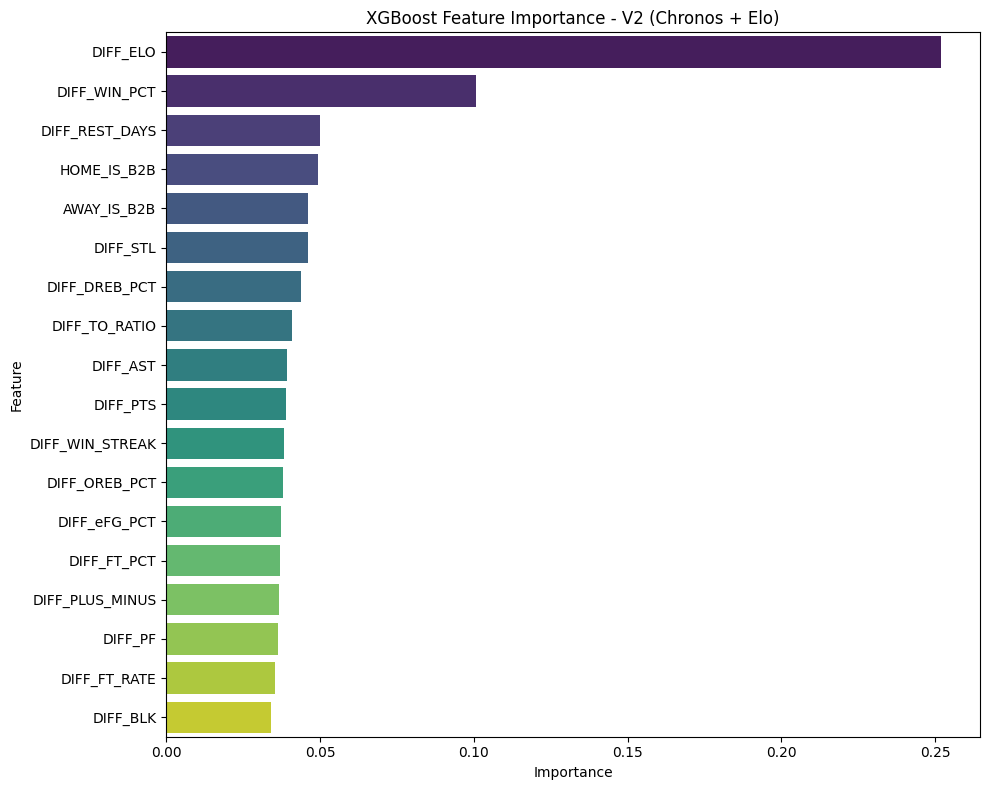

In [18]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Machine Learning
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# 1. Đọc dữ liệu và tự động nhận diện Features
print("1. ĐANG LOAD DỮ LIỆU...")

# Đọc file CSV
train_df = pd.read_csv('output/eval_train_v2.csv')
test_df = pd.read_csv('output/eval_test_v2.csv')

LABEL = 'HOME_WIN'

# SỬA LỖI: Tự động quét các cột bắt đầu bằng 'DIFF_' thay vì tìm trong JSON
FEATURES = [col for col in train_df.columns if col.startswith('DIFF_')]

# Thêm các cột không có tiền tố DIFF_ (như lịch thi đấu B2B)
for col in ['HOME_IS_B2B', 'AWAY_IS_B2B']:
    if col in train_df.columns:
        FEATURES.append(col)

print(f"[+] Đã tự động nhận diện {len(FEATURES)} features từ file CSV!")

X_train, y_train = train_df[FEATURES], train_df[LABEL]
X_test, y_test = test_df[FEATURES], test_df[LABEL]

print(f"[+] X_train shape: {X_train.shape} | y_train phân bố: {y_train.mean():.1%} Home Win")
print(f"[+] X_test shape:  {X_test.shape}  | y_test phân bố:  {y_test.mean():.1%} Home Win\n")

# 2. Huấn luyện mô hình Baseline (Logistic Regression) và XGBoost
print("2. ĐANG HUẤN LUYỆN MÔ HÌNH...")

# Mô hình 1: Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Mô hình 2: XGBoost 
xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=4,        
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print("[+] Huấn luyện xong!\n")

# 3. Đánh giá mô hình trên tập Test
print("3. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (OUT-OF-TIME)")
print("="*60)

def evaluate_model(name, model, X, y_true):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
    print(f"--- Mô hình: {name} ---")
    print(f"Accuracy : {acc:.4f} (Độ chính xác tổng thể)")
    print(f"ROC-AUC  : {auc:.4f} (Khả năng phân tách Thắng/Thua)")
    print(f"F1-Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Away Win (0)', 'Home Win (1)']))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Đoán Khách Thắng', 'Đoán Nhà Thắng'], 
                yticklabels=['Thực tế Khách Thắng', 'Thực tế Nhà Thắng'])
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    
    return model

evaluate_model("Logistic Regression Baseline", lr_model, X_test, y_test)
print("\n")
evaluate_model("XGBoost Classifier", xgb_model, X_test, y_test)

# 4. Phân tích Feature Importance của XGBoost
print("\n4. MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)")
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('XGBoost Feature Importance - V2 (Chronos + Elo)')
plt.tight_layout()
plt.show()